# World Model com Transição Difusiva para Dinâmica de Cripto

Pipeline completo: WM-Gauss (baseline) vs WM-Diff (DDPM condicional) para previsão
probabilística de retornos de BTC/USDT (1h).

**Modo de execução:** o notebook roda por padrão em `TEST_MODE = True` (dados curtos,
poucas épocas, poucos passos de difusão) para validar o pipeline ponta a ponta rapidamente.
Para o treino real, troque para `TEST_MODE = False` (constantes reais já deixadas comentadas
logo abaixo de cada constante de teste).

**Notas desta revisão:** baselines (Trivial/GARCH/LSTM) agora entram nas mesmas
métricas dos world models (seção 7.1 e 8); IC por bootstrap + teste de Wilcoxon
pareado para WM-Gauss vs. WM-Diff (seção 8.1); correção de um bug na quebra por
regime da seção 9 (o ELBO do WM-Diff era o mesmo valor repetido para todo o batch);
comentário sobre a leitura da mediana achatada no gráfico de preço (seção 11).


## 1. Configuração

In [1]:
import os, math, json, time, random
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)


device: cpu


In [2]:
# ============================================================
# TEST_MODE: liga constantes pequenas para validar o pipeline.
# Para o treino de verdade, defina TEST_MODE = False.
# ============================================================
TEST_MODE = False

SYMBOL = "BTCUSDT"
AUX_SYMBOL = "ETHUSDT"          # usado na validação cruzada de robustez (seção 9)
INTERVAL = "1h"

if TEST_MODE:
    # --- valores de teste (rápidos) ---
    HISTORY_DAYS = 60            # ~poucas semanas de klines
    CONTEXT_LEN = 24             # janela de contexto (passos de 1h)
    BATCH_SIZE = 64
    N_EPOCHS = 3
    DIFFUSION_STEPS_TRAIN = 20
    DIFFUSION_STEPS_DDIM_EVAL = 5
    ROLLOUT_HORIZONS = [1, 6, 24]
    N_ROLLOUT_SAMPLES = 32
else:
    HISTORY_DAYS = 1095          # ~2 anos de klines de 1h
    CONTEXT_LEN = 168
    BATCH_SIZE = 256
    N_EPOCHS = 50
    DIFFUSION_STEPS_TRAIN = 50
    DIFFUSION_STEPS_DDIM_EVAL = 10
    ROLLOUT_HORIZONS = [1, 24, 168]
    N_ROLLOUT_SAMPLES = 200
    
HIDDEN_DIM = 256
GRU_LAYERS = 2
LR = 1e-3
WEIGHT_DECAY = 0.0
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15   # resto (0.15) = teste
PICP_ALPHA = 0.90                    # intervalo de 90% para calibração
N_BOOTSTRAP = 200 if TEST_MODE else 2000   # reamostragens para IC bootstrap (seção 8.1)
CI_LEVEL = 0.90                            # nível de confiança dos intervalos bootstrap

print(f"TEST_MODE={TEST_MODE} | HISTORY_DAYS={HISTORY_DAYS} | N_EPOCHS={N_EPOCHS} | "
      f"DIFFUSION_STEPS_TRAIN={DIFFUSION_STEPS_TRAIN}")


TEST_MODE=False | HISTORY_DAYS=1095 | N_EPOCHS=50 | DIFFUSION_STEPS_TRAIN=50


## 2. Coleta de dados (Binance klines, sem chave)

A API pública limita 1000 candles por chamada (~42 dias em 1h), então paginamos com
`startTime`/`endTime` em milissegundos, concatenando os CSVs. O bruto é salvo em disco
para permitir reexecução sem novo download.

In [3]:
import requests

BINANCE_KLINES_URL = "https://api.binance.com/api/v3/klines"
KLINE_COLUMNS = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "trades",
    "taker_buy_base", "taker_buy_quote", "ignore",
]

def fetch_klines(symbol: str, interval: str, start_ms: int, end_ms: int,
                  limit: int = 1000, pause: float = 0.25) -> pd.DataFrame:
    """Baixa klines paginando por start_time/end_time até cobrir [start_ms, end_ms]."""
    all_rows = []
    cursor = start_ms
    while cursor < end_ms:
        params = {
            "symbol": symbol, "interval": interval,
            "startTime": cursor, "endTime": end_ms, "limit": limit,
        }
        resp = requests.get(BINANCE_KLINES_URL, params=params, timeout=30)
        resp.raise_for_status()
        rows = resp.json()
        if not rows:
            break
        all_rows.extend(rows)
        last_open_time = rows[-1][0]
        next_cursor = last_open_time + 1
        if next_cursor <= cursor:
            break
        cursor = next_cursor
        if len(rows) < limit:
            break
        time.sleep(pause)  # respeita rate limit
    if not all_rows:
        return pd.DataFrame(columns=KLINE_COLUMNS)
    df = pd.DataFrame(all_rows, columns=KLINE_COLUMNS)
    return df

def load_or_fetch(symbol: str, interval: str, history_days: int) -> pd.DataFrame:
    cache_path = DATA_DIR / f"{symbol}_{interval}_{history_days}d.csv"
    if cache_path.exists():
        print(f"[cache] {cache_path}")
        return pd.read_csv(cache_path)
    end_dt = pd.Timestamp.utcnow().floor("h")
    start_dt = end_dt - pd.Timedelta(days=history_days)
    df = fetch_klines(symbol, interval,
                       int(start_dt.timestamp() * 1000),
                       int(end_dt.timestamp() * 1000))
    df.to_csv(cache_path, index=False)
    print(f"[fetched] {cache_path} rows={len(df)}")
    return df

raw_df = load_or_fetch(SYMBOL, INTERVAL, HISTORY_DAYS)
raw_df.head()


C:\Users\Leoso\AppData\Local\Temp\ipykernel_17728\2801362561.py:44: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().floor("h")


[fetched] data\BTCUSDT_1h_1095d.csv rows=26281


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,ignore
0,1695265200000,26970.78000000,27035.44000000,26965.68000000,27035.00000000,614.61382000,1695268799999,16590992.42877140,20082,299.04757000,8073337.88816180,0
1,1695268800000,27034.99000000,27103.17000000,26991.06000000,27093.24000000,760.67327000,1695272399999,20576840.32521300,25878,454.64909000,12299996.36749560,0
2,1695272400000,27093.24000000,27096.36000000,27032.55000000,27071.02000000,534.97208000,1695275999999,14477514.78460770,21659,236.95560000,6412288.56456940,0
3,1695276000000,27071.03000000,27073.09000000,27005.00000000,27070.00000000,681.75513000,1695279599999,18433479.96884950,25097,375.81507000,10161376.57152150,0
4,1695279600000,27070.00000000,27070.09000000,26979.92000000,26990.11000000,916.55381000,1695283199999,24756682.99948190,25636,403.06332000,10885980.21489570,0


## 3. Pré-processamento e features

Do candle bruto derivam-se: log-retorno, range normalizado, volume/trades em log e
volatilidade realizada de 24h. Normalização por z-score com estatísticas do treino
apenas, aplicadas depois em val/teste. Split temporal estrito, sem embaralhamento.

In [4]:
def build_features(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()
    for col in ["open", "high", "low", "close", "volume", "trades"]:
        df[col] = df[col].astype(float)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")

    df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
    df["range_norm"] = (df["high"] - df["low"]) / df["close"]
    df["log_volume"] = np.log1p(df["volume"])
    df["log_trades"] = np.log1p(df["trades"])
    df["rv_24h"] = df["log_ret"].rolling(24).std()

    df = df.dropna().reset_index(drop=True)
    return df

FEATURE_COLS = ["log_ret", "range_norm", "log_volume", "log_trades", "rv_24h"]
TARGET_COL = "log_ret"  # o world model prevê o próximo vetor de observação; a cabeça
                          # probabilística é avaliada especificamente sobre log_ret

feat_df = build_features(raw_df)
print(feat_df.shape)
feat_df[FEATURE_COLS].describe()


(26257, 17)


,log_ret,range_norm,log_volume,log_trades,rv_24h
count,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000
mean,0.000042,0.006678,6.647228,11.454944,0.004432
std,0.004987,0.005421,0.822721,0.804168,0.002297
min,-0.050195,0.000179,3.859328,8.828934,0.000455
25%,-0.002012,0.003405,6.075759,10.865975,0.002879
50%,0.000040,0.005225,6.603309,11.406709,0.004044
75%,0.002151,0.008146,7.178041,11.997762,0.005434
max,0.051929,0.115579,10.224279,15.074042,0.021157


In [5]:
def temporal_split(df: pd.DataFrame, train_frac: float, val_frac: float):
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train = df.iloc[:n_train].reset_index(drop=True)
    val = df.iloc[n_train:n_train + n_val].reset_index(drop=True)
    test = df.iloc[n_train + n_val:].reset_index(drop=True)
    return train, val, test

train_df, val_df, test_df = temporal_split(feat_df, TRAIN_FRAC, VAL_FRAC)
print(f"train={len(train_df)} val={len(val_df)} test={len(test_df)}")

# z-score com estatísticas do treino apenas
feat_mean = train_df[FEATURE_COLS].mean()
feat_std = train_df[FEATURE_COLS].std().replace(0, 1e-8)

def normalize(df):
    out = df.copy()
    out[FEATURE_COLS] = (df[FEATURE_COLS] - feat_mean) / feat_std
    return out

train_norm = normalize(train_df)
val_norm = normalize(val_df)
test_norm = normalize(test_df)


train=18379 val=3938 test=3940


## 4. Dataset de janelas deslizantes

In [6]:
class WindowDataset(Dataset):
    """Cada item: contexto de CONTEXT_LEN passos + próxima observação (alvo)."""

    def __init__(self, df: pd.DataFrame, context_len: int):
        self.data = df[FEATURE_COLS].values.astype(np.float32)
        self.context_len = context_len
        self.n = len(self.data) - context_len - 1

    def __len__(self):
        return max(self.n, 0)

    def __getitem__(self, idx):
        ctx = self.data[idx: idx + self.context_len]
        target = self.data[idx + self.context_len]
        return torch.from_numpy(ctx), torch.from_numpy(target)

train_ds = WindowDataset(train_norm, CONTEXT_LEN)
val_ds = WindowDataset(val_norm, CONTEXT_LEN)
test_ds = WindowDataset(test_norm, CONTEXT_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"train_ds={len(train_ds)} val_ds={len(val_ds)} test_ds={len(test_ds)}")


train_ds=18210 val_ds=3769 test_ds=3771


## 5. Arquitetura do world model

Ambos os modelos compartilham a recorrência GRU (encoder de contexto -> estado oculto h_t).
Diferem apenas na cabeça de transição:
- **WM-Gauss:** emite (mu, log_sigma) de uma gaussiana diagonal sobre a próxima observação.
- **WM-Diff:** DDPM condicional (rede epsilon) que modela a mesma condicional via denoising.

In [7]:
OBS_DIM = len(FEATURE_COLS)

class GRUEncoder(nn.Module):
    """Consome a sequência de observações e retorna o estado oculto final h_t."""

    def __init__(self, obs_dim=OBS_DIM, hidden_dim=HIDDEN_DIM, n_layers=GRU_LAYERS):
        super().__init__()
        self.gru = nn.GRU(obs_dim, hidden_dim, num_layers=n_layers, batch_first=True)

    def forward(self, ctx):  # ctx: (B, T, obs_dim)
        _, h_n = self.gru(ctx)
        return h_n[-1]  # (B, hidden_dim)


class GaussianHead(nn.Module):
    """Cabeça de transição gaussiana diagonal: p(o_{t+1} | h_t)."""

    def __init__(self, hidden_dim=HIDDEN_DIM, obs_dim=OBS_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 2 * obs_dim),
        )
        self.obs_dim = obs_dim

    def forward(self, h):
        out = self.net(h)
        mu, log_sigma = out.chunk(2, dim=-1)
        log_sigma = log_sigma.clamp(-7, 3)
        return mu, log_sigma

    def nll(self, h, target):
        mu, log_sigma = self(h)
        sigma = log_sigma.exp()
        dist = torch.distributions.Normal(mu, sigma)
        return -dist.log_prob(target).sum(dim=-1)

    @torch.no_grad()
    def sample(self, h, n_samples=1):
        mu, log_sigma = self(h)
        sigma = log_sigma.exp()
        mu = mu.unsqueeze(0).expand(n_samples, *mu.shape)
        sigma = sigma.unsqueeze(0).expand(n_samples, *sigma.shape)
        return mu + sigma * torch.randn_like(mu)


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):  # t: (B,) int
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / half)
        args = t.float().unsqueeze(-1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2:
            emb = F.pad(emb, (0, 1))
        return emb


class DiffusionHead(nn.Module):
    """DDPM condicional: rede epsilon(x_k, k, h) treinada com objetivo de denoising padrão."""

    def __init__(self, hidden_dim=HIDDEN_DIM, obs_dim=OBS_DIM, n_steps=DIFFUSION_STEPS_TRAIN,
                 time_emb_dim=32):
        super().__init__()
        self.obs_dim = obs_dim
        self.n_steps = n_steps

        betas = torch.linspace(1e-4, 0.02, n_steps)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)

        self.time_emb = SinusoidalTimeEmbedding(time_emb_dim)
        self.eps_net = nn.Sequential(
            nn.Linear(obs_dim + hidden_dim + time_emb_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, obs_dim),
        )

    def predict_eps(self, x_k, k, h):
        t_emb = self.time_emb(k)
        inp = torch.cat([x_k, h, t_emb], dim=-1)
        return self.eps_net(inp)

    def loss(self, h, target, reduction="mean"):
        """Objetivo padrão de denoising DDPM (equivalente ao ELBO simplificado).

        reduction="mean" (padrão, usado no treino): escalar único para backward().
        reduction="none": proxy de ELBO por exemplo do batch (média do MSE de
        denoising nas dimensões de features) — necessário sempre que o valor for
        usado por amostra em vez de só como loss agregada de treino/validação
        (ver seção 9, onde usar só a média do batch mascarava diferenças reais)."""
        B = target.shape[0]
        k = torch.randint(0, self.n_steps, (B,), device=target.device)
        a_bar = self.alphas_cumprod[k].unsqueeze(-1)
        noise = torch.randn_like(target)
        x_k = a_bar.sqrt() * target + (1 - a_bar).sqrt() * noise
        eps_pred = self.predict_eps(x_k, k, h)
        if reduction == "none":
            return F.mse_loss(eps_pred, noise, reduction="none").mean(dim=-1)
        return F.mse_loss(eps_pred, noise)

    @torch.no_grad()
    def sample_ddpm(self, h, n_samples=1):
        """Amostragem ancestral completa (n_steps passos) — usada no treino/validação."""
        B = h.shape[0]
        h_rep = h.unsqueeze(0).expand(n_samples, B, -1).reshape(n_samples * B, -1)
        x = torch.randn(n_samples * B, self.obs_dim, device=h.device)
        for k in reversed(range(self.n_steps)):
            k_batch = torch.full((n_samples * B,), k, device=h.device, dtype=torch.long)
            eps_pred = self.predict_eps(x, k_batch, h_rep)
            alpha = self.alphas[k]
            alpha_bar = self.alphas_cumprod[k]
            beta = self.betas[k]
            coef = (1 - alpha) / (1 - alpha_bar).sqrt()
            mean = (1 / alpha.sqrt()) * (x - coef * eps_pred)
            if k > 0:
                noise = torch.randn_like(x)
                x = mean + beta.sqrt() * noise
            else:
                x = mean
        return x.view(n_samples, B, self.obs_dim)

    @torch.no_grad()
    def sample_ddim(self, h, n_samples=1, n_steps_eval=DIFFUSION_STEPS_DDIM_EVAL):
        """DDIM com poucos passos — usado na avaliação/rollout para viabilizar custo."""
        B = h.shape[0]
        h_rep = h.unsqueeze(0).expand(n_samples, B, -1).reshape(n_samples * B, -1)
        step_indices = torch.linspace(0, self.n_steps - 1, n_steps_eval, device=h.device).long()
        step_indices = torch.unique(step_indices, sorted=True).flip(0)  # decrescente
        x = torch.randn(n_samples * B, self.obs_dim, device=h.device)
        for i, k in enumerate(step_indices):
            k_batch = torch.full((n_samples * B,), int(k), device=h.device, dtype=torch.long)
            eps_pred = self.predict_eps(x, k_batch, h_rep)
            alpha_bar_k = self.alphas_cumprod[k]
            x0_pred = (x - (1 - alpha_bar_k).sqrt() * eps_pred) / alpha_bar_k.sqrt()
            if i + 1 < len(step_indices):
                k_next = step_indices[i + 1]
                alpha_bar_next = self.alphas_cumprod[k_next]
            else:
                alpha_bar_next = torch.tensor(1.0, device=h.device)
            x = alpha_bar_next.sqrt() * x0_pred + (1 - alpha_bar_next).sqrt() * eps_pred
        return x.view(n_samples, B, self.obs_dim)

class WorldModel(nn.Module):
    """Wrapper comum: encoder GRU + cabeça de transição (gauss ou diff)."""

    def __init__(self, head_type: str, **head_kwargs):
        super().__init__()
        assert head_type in ("gauss", "diff")
        self.head_type = head_type
        self.encoder = GRUEncoder()
        if head_type == "gauss":
            self.head = GaussianHead(**head_kwargs)
        else:
            self.head = DiffusionHead(**head_kwargs)

    def encode(self, ctx):
        return self.encoder(ctx)

    def step_loss(self, ctx, target):
        h = self.encode(ctx)
        if self.head_type == "gauss":
            return self.head.nll(h, target).mean()
        return self.head.loss(h, target)

    @torch.no_grad()
    def sample_next(self, ctx, n_samples=1, fast_eval=True):
        h = self.encode(ctx)
        if self.head_type == "gauss":
            return self.head.sample(h, n_samples=n_samples)
        if fast_eval:
            return self.head.sample_ddim(h, n_samples=n_samples)
        return self.head.sample_ddpm(h, n_samples=n_samples)


## 6. Treinamento

In [8]:
def train_model(model: WorldModel, train_loader, val_loader,
                 n_epochs=N_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                 patience=5, tag="model"):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        for ctx, target in train_loader:
            ctx, target = ctx.to(DEVICE), target.to(DEVICE)
            opt.zero_grad()
            loss = model.step_loss(ctx, target)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for ctx, target in val_loader:
                ctx, target = ctx.to(DEVICE), target.to(DEVICE)
                val_losses.append(model.step_loss(ctx, target).item())

        train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
        val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        sched.step(val_loss)
        print(f"[{tag}] epoch {epoch+1}/{n_epochs} train={train_loss:.4f} val={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{tag}] early stopping na época {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [9]:
wm_gauss = WorldModel("gauss")
wm_gauss, hist_gauss = train_model(wm_gauss, train_loader, val_loader, tag="WM-Gauss")
torch.save(wm_gauss.state_dict(), CKPT_DIR / "wm_gauss.pt")


[WM-Gauss] epoch 1/50 train=4.3927 val=3.7675
[WM-Gauss] epoch 2/50 train=3.5065 val=3.6699
[WM-Gauss] epoch 3/50 train=3.3839 val=3.8471
[WM-Gauss] epoch 4/50 train=3.3536 val=3.7378
[WM-Gauss] epoch 5/50 train=3.3354 val=3.6067
[WM-Gauss] epoch 6/50 train=3.2885 val=3.7751
[WM-Gauss] epoch 7/50 train=3.2135 val=3.5863
[WM-Gauss] epoch 8/50 train=3.1396 val=3.5547
[WM-Gauss] epoch 9/50 train=3.1238 val=3.6152
[WM-Gauss] epoch 10/50 train=3.1109 val=4.2583
[WM-Gauss] epoch 11/50 train=3.1136 val=3.5195
[WM-Gauss] epoch 12/50 train=3.1130 val=3.5871
[WM-Gauss] epoch 13/50 train=3.0147 val=3.4067
[WM-Gauss] epoch 14/50 train=2.9662 val=3.4910
[WM-Gauss] epoch 15/50 train=2.9048 val=3.4871
[WM-Gauss] epoch 16/50 train=2.8965 val=3.4835
[WM-Gauss] epoch 17/50 train=2.7454 val=3.5534
[WM-Gauss] epoch 18/50 train=2.7289 val=3.3272
[WM-Gauss] epoch 19/50 train=2.6695 val=3.3458
[WM-Gauss] epoch 20/50 train=2.6455 val=3.3072
[WM-Gauss] epoch 21/50 train=2.5823 val=3.4495
[WM-Gauss] epoch 22/50

In [10]:
wm_diff = WorldModel("diff", n_steps=DIFFUSION_STEPS_TRAIN)
wm_diff, hist_diff = train_model(wm_diff, train_loader, val_loader, tag="WM-Diff")
torch.save(wm_diff.state_dict(), CKPT_DIR / "wm_diff.pt")


[WM-Diff] epoch 1/50 train=0.7723 val=0.6093
[WM-Diff] epoch 2/50 train=0.5683 val=0.5524
[WM-Diff] epoch 3/50 train=0.5323 val=0.5469
[WM-Diff] epoch 4/50 train=0.5100 val=0.5339
[WM-Diff] epoch 5/50 train=0.4972 val=0.5238
[WM-Diff] epoch 6/50 train=0.4981 val=0.5063
[WM-Diff] epoch 7/50 train=0.4852 val=0.5021
[WM-Diff] epoch 8/50 train=0.4832 val=0.5124
[WM-Diff] epoch 9/50 train=0.4861 val=0.5130
[WM-Diff] epoch 10/50 train=0.4882 val=0.5086
[WM-Diff] epoch 11/50 train=0.4699 val=0.5109
[WM-Diff] epoch 12/50 train=0.4734 val=0.5180
[WM-Diff] early stopping na época 12


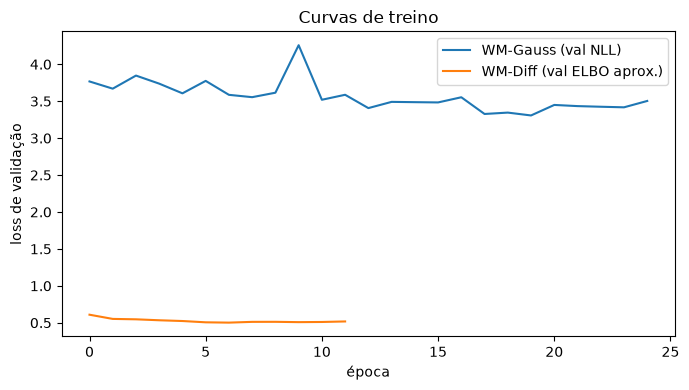

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_gauss["val_loss"], label="WM-Gauss (val NLL)")
ax.plot(hist_diff["val_loss"], label="WM-Diff (val ELBO aprox.)")
ax.set_xlabel("época"); ax.set_ylabel("loss de validação"); ax.legend()
ax.set_title("Curvas de treino")
plt.tight_layout()
plt.savefig(FIG_DIR / "curvas_treino.png", dpi=120)
plt.show()


## 7. Baselines

- **Trivial:** drift (média histórica) + gaussiana fixa.
- **GARCH(1,1)/EGARCH:** referência econométrica de volatilidade (requer `pip install arch`).
- **LSTM 1 passo (opcional):** mesma cabeça gaussiana, recorrência LSTM — isola se o ganho
  vem da difusão ou apenas da recorrência.

Interface unificada com os world models (para que a comparação nas seções 8+ seja direta) fica na seção 7.1.


In [12]:
class TrivialBaseline:
    """Drift = média do treino; variância = variância do treino (gaussiana fixa)."""

    def __init__(self, train_returns: np.ndarray):
        self.mu = float(np.mean(train_returns))
        self.sigma = float(np.std(train_returns) + 1e-8)

    def nll(self, targets: np.ndarray) -> np.ndarray:
        dist = torch.distributions.Normal(self.mu, self.sigma)
        return -dist.log_prob(torch.from_numpy(targets)).numpy()

    def sample(self, n_samples: int, n_points: int) -> np.ndarray:
        return self.mu + self.sigma * np.random.randn(n_samples, n_points)


train_returns_raw = train_df[TARGET_COL].values
trivial = TrivialBaseline(train_returns_raw)
print(f"trivial: mu={trivial.mu:.6f} sigma={trivial.sigma:.6f}")


trivial: mu=0.000079 sigma=0.005092


In [13]:
# GARCH(1,1) via pacote `arch` (referência econométrica de volatilidade).
# Se o pacote não estiver instalado neste ambiente, instale com:
#   pip install arch --break-system-packages
try:
    from arch import arch_model

    garch_res = arch_model(
        train_returns_raw * 100, mean="Constant", vol="GARCH", p=1, q=1, dist="normal"
    ).fit(disp="off")
    print(garch_res.summary())
    GARCH_AVAILABLE = True
except ImportError:
    print("pacote `arch` não disponível — pulando baseline GARCH nesta execução.")
    GARCH_AVAILABLE = False


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -11363.7
Distribution:                  Normal   AIC:                           22735.3
Method:            Maximum Likelihood   BIC:                           22766.6
                                        No. Observations:                18379
Date:                Sun, Sep 20 2026   Df Residuals:                    18378
Time:                        03:50:59   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         2.9589e-03  2.875e-03      1.029      0.303 

In [14]:
import torch
import torch.nn as nn
import numpy as np

class OneStepLSTM(nn.Module):
    """Baseline competitiva: Encoders/Decoders MLP, LayerNorm e LSTM profunda."""
    head_type = "gauss"

    def __init__(self, obs_dim=OBS_DIM, hidden_dim=HIDDEN_DIM, num_layers=2):
        super().__init__()
        
        # 1. Feature Extractor (Encoder): Prepara a observação para a LSTM
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU() # SiLU (Swish) costuma performar melhor que ReLU em world models
        )
        
        # 2. LSTM mais profunda e com dropout entre as camadas
        self.lstm = nn.LSTM(
            hidden_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=0.1 if num_layers > 1 else 0.0
        )
        
        # 3. Processamento de saída (Decoder): Prepara o estado oculto para a Head
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU()
        )
        
        self.head = GaussianHead(hidden_dim, obs_dim)

    def encode(self, ctx):
        # ctx shape: (Batch, SeqLen, ObsDim)
        x = self.encoder(ctx) # Extrai features passo a passo
        
        _, (h_n, _) = self.lstm(x)
        # h_n contém o estado oculto de todas as camadas. Pegamos a última camada: [-1]
        last_hidden = h_n[-1] 
        
        # Passamos pelo MLP final antes da cabeça gaussiana
        return self.decoder(last_hidden)

    def step_loss(self, ctx, target):
        h = self.encode(ctx)
        return self.head.nll(h, target).mean()

    @torch.no_grad()
    def sample_next(self, ctx, n_samples=1, fast_eval=True):
        h = self.encode(ctx)
        return self.head.sample(h, n_samples=n_samples)


lstm_baseline = OneStepLSTM(obs_dim=OBS_DIM, hidden_dim=HIDDEN_DIM, num_layers=2).to(DEVICE)
opt_lstm = torch.optim.AdamW(lstm_baseline.parameters(), lr=LR, weight_decay=1e-4) # AdamW ajuda na regularização

# Opcional, mas recomendado: reduz o LR aos poucos
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt_lstm, T_max=N_EPOCHS)

for epoch in range(N_EPOCHS):
    lstm_baseline.train()
    losses = []
    
    for ctx, target in train_loader:
        ctx, target = ctx.to(DEVICE), target.to(DEVICE)
        
        opt_lstm.zero_grad()
        loss = lstm_baseline.step_loss(ctx, target)
        loss.backward()
        
        # ESSENCIAL: Evita "exploding gradients" típicos de RNNs
        torch.nn.utils.clip_grad_norm_(lstm_baseline.parameters(), max_norm=1.0)
        
        opt_lstm.step()
        losses.append(loss.item())
    
    scheduler.step() # Atualiza o learning rate
    
    current_lr = scheduler.get_last_lr()[0]
    print(f"[LSTM] epoch {epoch+1}/{N_EPOCHS} train_loss={np.mean(losses):.4f} lr={current_lr:.6f}")

[LSTM] epoch 1/50 train_loss=4.2945 lr=0.000999
[LSTM] epoch 2/50 train_loss=3.6568 lr=0.000996
[LSTM] epoch 3/50 train_loss=3.5301 lr=0.000991
[LSTM] epoch 4/50 train_loss=3.5179 lr=0.000984
[LSTM] epoch 5/50 train_loss=3.4396 lr=0.000976
[LSTM] epoch 6/50 train_loss=3.3565 lr=0.000965
[LSTM] epoch 7/50 train_loss=3.3614 lr=0.000952
[LSTM] epoch 8/50 train_loss=3.2971 lr=0.000938
[LSTM] epoch 9/50 train_loss=3.2358 lr=0.000922
[LSTM] epoch 10/50 train_loss=3.1989 lr=0.000905
[LSTM] epoch 11/50 train_loss=3.1151 lr=0.000885
[LSTM] epoch 12/50 train_loss=3.0578 lr=0.000864
[LSTM] epoch 13/50 train_loss=2.9652 lr=0.000842
[LSTM] epoch 14/50 train_loss=2.9046 lr=0.000819
[LSTM] epoch 15/50 train_loss=2.8329 lr=0.000794
[LSTM] epoch 16/50 train_loss=2.7872 lr=0.000768
[LSTM] epoch 17/50 train_loss=2.7104 lr=0.000741
[LSTM] epoch 18/50 train_loss=2.5870 lr=0.000713
[LSTM] epoch 19/50 train_loss=2.5315 lr=0.000684
[LSTM] epoch 20/50 train_loss=2.4610 lr=0.000655
[LSTM] epoch 21/50 train_loss

## 7.1 Baselines com interface unificada

Para a comparação com os world models ser direta (mesmas métricas, mesmos pontos de
partida no teste, mesmo `rollout` autoregressivo), os baselines abaixo são
empacotados na mesma interface de `WorldModel` (`head_type`, `.encode(ctx)`,
`.head.sample(h, n_samples)`, `.head.nll(h, target)`). Isso permite reaproveitar
`rollout`, `evaluate_horizons`, `wasserstein_by_horizon` e `one_step_nll_test` sem
duplicar lógica de avaliação.

- **Trivial:** todas as features ~ N(0, 1) i.i.d. no espaço normalizado — equivale a
  "drift = média do treino, variância = variância do treino", já que a normalização
  usa exatamente essas estatísticas.
- **GARCH(1,1):** a variância de `log_ret` evolui pela recursão padrão
  σ²ₜ = ω + α·ε²ₜ₋₁ + β·σ²ₜ₋₁, filtrada sobre o contexto (dados reais no início do
  rollout, depois sobre os próprios valores gerados — mesmo esquema autoregressivo
  usado pelos world models). As demais features usam a distribuição trivial.
  Limitação conhecida: o burn-in da variância é só o contexto (`CONTEXT_LEN`
  passos), o que pode subestimar a persistência real se α+β estiver muito próximo
  de 1 (não refazemos o fit do GARCH em cada janela, por custo).


In [15]:
class BaselineGaussianHead:
    """Cabeça gaussiana diagonal com (mu, sigma) fornecidos externamente (não
    aprendidos) — mesma interface de GaussianHead.sample/.nll, usada pelos baselines."""

    def nll(self, h, target):
        mu, sigma = h
        dist = torch.distributions.Normal(mu, sigma)
        return -dist.log_prob(target).sum(dim=-1)

    def sample(self, h, n_samples=1):
        mu, sigma = h
        mu = mu.unsqueeze(0).expand(n_samples, *mu.shape)
        sigma = sigma.unsqueeze(0).expand(n_samples, *sigma.shape)
        return mu + sigma * torch.randn_like(mu)


class BaselineModel:
    """Empacota um baseline não-aprendido (trivial, GARCH) na interface de WorldModel,
    para reuso direto de rollout / evaluate_horizons / wasserstein_by_horizon /
    one_step_nll_test."""

    head_type = "gauss"

    def __init__(self, encode_fn, name):
        self._encode_fn = encode_fn
        self.head = BaselineGaussianHead()
        self.name = name

    def to(self, device):
        return self

    def eval(self):
        return self

    def encode(self, ctx):
        return self._encode_fn(ctx)

    @torch.no_grad()
    def sample_next(self, ctx, n_samples=1, fast_eval=True):
        h = self.encode(ctx)
        return self.head.sample(h, n_samples=n_samples)


# --- Trivial: N(0, 1) i.i.d. por feature no espaço normalizado ---
_trivial_mu = torch.tensor(train_norm[FEATURE_COLS].mean().values, dtype=torch.float32)
_trivial_sigma = torch.tensor(train_norm[FEATURE_COLS].std().values,
                               dtype=torch.float32).clamp_min(1e-6)

def _trivial_encode(ctx):
    B = ctx.shape[0]
    mu = _trivial_mu.to(ctx.device).unsqueeze(0).expand(B, -1)
    sigma = _trivial_sigma.to(ctx.device).unsqueeze(0).expand(B, -1)
    return mu, sigma

trivial_model = BaselineModel(_trivial_encode, "Trivial")


# --- GARCH(1,1): variância de log_ret evolui pela recursão; demais features triviais ---
def _make_garch_encode():
    ret_idx = FEATURE_COLS.index(TARGET_COL)
    omega = garch_res.params["omega"] / (100.0 ** 2)   # desfaz o *100 usado no fit
    alpha1 = garch_res.params["alpha[1]"]
    beta1 = garch_res.params["beta[1]"]
    mu_r = garch_res.params["mu"] / 100.0
    persist = alpha1 + beta1
    uncond_var = omega / max(1e-6, 1 - persist) if persist < 1 else float(train_returns_raw.var())
    ret_mean_train = float(feat_mean[TARGET_COL])
    ret_std_train = float(feat_std[TARGET_COL])
    mu_ret_norm = (mu_r - ret_mean_train) / ret_std_train

    def encode(ctx):
        ret_norm = ctx[:, :, ret_idx].detach().cpu().numpy()
        ret_raw = ret_norm * ret_std_train + ret_mean_train
        eps = ret_raw - mu_r
        B, T = eps.shape
        sigma2 = np.full(B, uncond_var, dtype=np.float64)
        for t in range(T):
            sigma2 = omega + alpha1 * eps[:, t] ** 2 + beta1 * sigma2
        sigma_ret_raw = np.sqrt(np.maximum(sigma2, 1e-12))
        sigma_ret_norm = sigma_ret_raw / ret_std_train

        mu = _trivial_mu.to(ctx.device).unsqueeze(0).expand(B, -1).clone()
        sigma = _trivial_sigma.to(ctx.device).unsqueeze(0).expand(B, -1).clone()
        mu[:, ret_idx] = mu_ret_norm
        sigma[:, ret_idx] = torch.from_numpy(sigma_ret_norm.astype(np.float32)).to(ctx.device)
        return mu, sigma

    return encode

if GARCH_AVAILABLE:
    garch_model = BaselineModel(_make_garch_encode(), "GARCH(1,1)")
else:
    garch_model = None
    print("GARCH indisponível — baseline GARCH será omitido das comparações.")


## 8. Avaliação

Três níveis: (1) NLL de um passo no teste; (2) CRPS/pinball/PICP em horizontes fixos;
(3) qualidade de rollout multipassos via distância de Wasserstein-1 e estatísticas
sumárias (volatilidade, assimetria, curtose).

In [16]:
@torch.no_grad()
def one_step_nll_test(model, loader) -> float:
    model.eval()
    nlls = []
    for ctx, target in loader:
        ctx, target = ctx.to(DEVICE), target.to(DEVICE)
        h = model.encode(ctx)
        if model.head_type == "gauss":
            nll = model.head.nll(h, target)
        else:
            # NLL exata não é tratável para DDPM; usamos o ELBO simplificado (MSE de
            # denoising) por exemplo (reduction="none") como proxy — não mais a loss
            # média do batch repetida (ver bug corrigido na seção 9).
            nll = model.head.loss(h, target, reduction="none")
        nlls.append(nll.cpu().numpy())
    return float(np.concatenate(nlls).mean())

nll_gauss_test = one_step_nll_test(wm_gauss, test_loader)
elbo_diff_test = one_step_nll_test(wm_diff, test_loader)
nll_trivial_test = one_step_nll_test(trivial_model, test_loader)
nll_lstm_test = one_step_nll_test(lstm_baseline, test_loader)
nll_garch_test = one_step_nll_test(garch_model, test_loader) if GARCH_AVAILABLE else None

_rows = [("Trivial", nll_trivial_test), ("LSTM (gauss)", nll_lstm_test)]
if GARCH_AVAILABLE:
    _rows.append(("GARCH(1,1)", nll_garch_test))
_rows += [("WM-Gauss (NLL exata)", nll_gauss_test), ("WM-Diff (ELBO proxy)", elbo_diff_test)]
one_step_comparison = pd.DataFrame(_rows, columns=["modelo", "nll_ou_elbo_1passo"])
print(one_step_comparison)
print("\nAtenção: WM-Diff usa um proxy de ELBO (MSE de denoising), não a NLL gaussiana "
      "exata dos demais — comparável em tendência/ranking, não em escala absoluta.")


                 modelo  nll_ou_elbo_1passo
0               Trivial            6.610907
1          LSTM (gauss)            5.306265
2            GARCH(1,1)            6.463019
3  WM-Gauss (NLL exata)            2.334976
4  WM-Diff (ELBO proxy)            0.492640

Atenção: WM-Diff usa um proxy de ELBO (MSE de denoising), não a NLL gaussiana exata dos demais — comparável em tendência/ranking, não em escala absoluta.


In [17]:
def crps_from_samples(samples: np.ndarray, target: float) -> float:
    """CRPS empírico (fórmula de Gneiting) a partir de um ensemble de amostras 1D."""
    samples = np.sort(samples)
    n = len(samples)
    term1 = np.mean(np.abs(samples - target))
    term2 = 0.0
    for i in range(n):
        term2 += np.sum(np.abs(samples[i] - samples[i + 1:]))
    term2 = term2 * 2 / (n * n)
    return term1 - 0.5 * term2


def pinball_loss(samples: np.ndarray, target: float, quantiles=(0.05, 0.5, 0.95)) -> dict:
    out = {}
    for q in quantiles:
        pred_q = np.quantile(samples, q)
        diff = target - pred_q
        out[q] = max(q * diff, (q - 1) * diff)
    return out


@torch.no_grad()
def rollout(model: WorldModel, init_ctx: torch.Tensor, horizon: int, n_samples: int,
            fast_eval=True) -> np.ndarray:
    """Amostra `n_samples` trajetórias futuras de `horizon` passos a partir de init_ctx.
    Retorna array (n_samples, horizon, obs_dim)."""
    model.eval()
    B = init_ctx.shape[0]
    assert B == 1, "rollout espera um único ponto de partida por chamada"
    ctx = init_ctx.repeat(n_samples, 1, 1).to(DEVICE)  # (n_samples, T, obs_dim)
    trajectory = np.zeros((n_samples, horizon, OBS_DIM), dtype=np.float32)
    for t in range(horizon):
        h = model.encode(ctx)
        if model.head_type == "gauss":
            next_obs = model.head.sample(h, n_samples=1).squeeze(0)
        else:
            next_obs = model.head.sample_ddim(h, n_samples=1).squeeze(0) if fast_eval \
                else model.head.sample_ddpm(h, n_samples=1).squeeze(0)
        trajectory[:, t, :] = next_obs.cpu().numpy()
        ctx = torch.cat([ctx[:, 1:, :], next_obs.unsqueeze(1)], dim=1)
    return trajectory


In [ ]:
def evaluate_horizons(model, test_norm_df: pd.DataFrame, horizons, n_samples):
    """Nível 2: CRPS/pinball/PICP em horizontes fixos, para pontos de partida amostrados
    do teste (apenas em log_ret, primeira coluna de FEATURE_COLS).

    Guarda `start` em cada registro para permitir comparações pareadas entre modelos
    (mesmos pontos de partida => bootstrap e teste de significância válidos, seção 8.1).
    """
    data = test_norm_df[FEATURE_COLS].values.astype(np.float32)
    max_h = max(horizons)
    starts = list(range(0, len(data) - CONTEXT_LEN - max_h, max(1, (len(data) // 20))))
    ret_idx = FEATURE_COLS.index(TARGET_COL)

    records = []
    for start in starts:
        ctx = torch.from_numpy(data[start: start + CONTEXT_LEN]).unsqueeze(0)
        traj = rollout(model, ctx, horizon=max_h, n_samples=n_samples)  # (S, H, obs_dim)
        for h in horizons:
            realized = data[start + CONTEXT_LEN + h - 1, ret_idx]
            samples_h = traj[:, h - 1, ret_idx]
            crps = crps_from_samples(samples_h, realized)
            pin = pinball_loss(samples_h, realized)
            lo, hi = np.quantile(samples_h, [(1 - PICP_ALPHA) / 2, 1 - (1 - PICP_ALPHA) / 2])
            covered = lo <= realized <= hi
            records.append({"start": start, "horizon": h, "crps": crps,
                             "pinball_median": pin[0.5], "covered": covered})
    return pd.DataFrame(records)


MODELS_FOR_EVAL = [("Trivial", trivial_model), ("LSTM (gauss)", lstm_baseline)]
if GARCH_AVAILABLE:
    MODELS_FOR_EVAL.append(("GARCH(1,1)", garch_model))
MODELS_FOR_EVAL += [("WM-Gauss", wm_gauss), ("WM-Diff", wm_diff)]

eval_dfs = {}
for _name, _mdl in MODELS_FOR_EVAL:
    print(f"avaliando {_name}...")
    eval_dfs[_name] = evaluate_horizons(_mdl, test_norm, ROLLOUT_HORIZONS, N_ROLLOUT_SAMPLES)

# nomes usados nas seções seguintes (regime, figuras) que já assumiam esses atalhos
eval_df_gauss, eval_df_diff = eval_dfs["WM-Gauss"], eval_dfs["WM-Diff"]

summaries = {
    _name: _df.groupby("horizon").agg(crps=("crps", "mean"),
                                       pinball_median=("pinball_median", "mean"),
                                       picp=("covered", "mean"))
    for _name, _df in eval_dfs.items()
}
summary_gauss, summary_diff = summaries["WM-Gauss"], summaries["WM-Diff"]

for _name, _s in summaries.items():
    print(f"\n{_name}:\n", _s)


avaliando Trivial...
avaliando LSTM (gauss)...


### 8.1 Intervalos de confiança (bootstrap) e teste de significância pareado

Com poucos pontos de partida por horizonte (`~len(test)//20`, e menos ainda
independentes nos horizontes maiores, que se sobrepõem no tempo), a média pontual
de CRPS/PICP nas tabelas acima tem variância alta — comparar só as médias pode
sugerir um "vencedor" que não é estatisticamente robusto. Esta seção:

1. calcula um intervalo de confiança por bootstrap (reamostrando as janelas
   `start`, não amostras individuais do modelo) para o CRPS médio de cada horizonte;
2. compara WM-Gauss vs. WM-Diff com um teste de Wilcoxon pareado por `start`
   (válido porque ambos foram avaliados exatamente nos mesmos pontos de partida).


In [ ]:
from scipy.stats import wilcoxon

def bootstrap_ci(values, n_boot=N_BOOTSTRAP, ci=CI_LEVEL, seed=0):
    """IC por bootstrap não-paramétrico sobre a média de `values` (uma linha por
    janela de teste, não por amostra individual gerada pelo modelo)."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = values[idx].mean(axis=1)
    lo, hi = np.quantile(boot_means, [(1 - ci) / 2, 1 - (1 - ci) / 2])
    return float(values.mean()), float(lo), float(hi)


def summarize_with_ci(eval_df: pd.DataFrame, metric="crps"):
    rows = []
    for h, g in eval_df.groupby("horizon"):
        mean, lo, hi = bootstrap_ci(g[metric].values)
        rows.append({"horizon": h, f"{metric}_mean": mean, f"{metric}_ci_lo": lo,
                     f"{metric}_ci_hi": hi, "n_windows": len(g)})
    return pd.DataFrame(rows).set_index("horizon")


def paired_significance(eval_df_a: pd.DataFrame, eval_df_b: pd.DataFrame,
                         name_a: str, name_b: str, metric="crps"):
    """Wilcoxon pareado por `start`, horizonte a horizonte. Só é válido porque ambos
    os modelos foram avaliados exatamente nos mesmos pontos de partida."""
    rows = []
    for h in sorted(eval_df_a["horizon"].unique()):
        a = eval_df_a[eval_df_a.horizon == h].set_index("start")[metric]
        b = eval_df_b[eval_df_b.horizon == h].set_index("start")[metric]
        common = a.index.intersection(b.index)
        if len(common) < 5:
            continue
        da, db = a.loc[common].values, b.loc[common].values
        if np.allclose(da, db):
            p = 1.0
        else:
            _, p = wilcoxon(da, db)
        rows.append({"horizon": h, "n_pairs": len(common),
                     f"crps_medio_{name_a}": da.mean(), f"crps_medio_{name_b}": db.mean(),
                     "wilcoxon_p": p})
    return pd.DataFrame(rows)


print("IC bootstrap do CRPS por horizonte:")
for _name, _df in eval_dfs.items():
    print(f"\n{_name}:\n", summarize_with_ci(_df, metric="crps"))

print("\nWM-Gauss vs. WM-Diff — teste pareado de Wilcoxon (CRPS):")
sig_df = paired_significance(eval_df_gauss, eval_df_diff, "WM-Gauss", "WM-Diff", metric="crps")
print(sig_df)
print("\nAtenção: n_pairs é pequeno (poucas dezenas por horizonte) — mesmo p-valores "
      "baixos devem ser lidos com cautela, não são dezenas de janelas independentes.")


IC bootstrap do CRPS por horizonte:

Trivial:
          crps_mean  crps_ci_lo  crps_ci_hi  n_windows
horizon                                              
1         0.389131    0.308589    0.497414         19
24        0.586246    0.376189    0.883425         19
168       0.302096    0.267391    0.345532         19

LSTM (gauss):
          crps_mean  crps_ci_lo  crps_ci_hi  n_windows
horizon                                              
1         0.355797    0.272253    0.456844         19
24        0.590089    0.372885    0.880551         19
168       0.305291    0.268897    0.350192         19

GARCH(1,1):
          crps_mean  crps_ci_lo  crps_ci_hi  n_windows
horizon                                              
1         0.357117    0.275951    0.454491         19
24        0.577087    0.376001    0.848457         19
168       0.332047    0.301124    0.368556         19

WM-Gauss:
          crps_mean  crps_ci_lo  crps_ci_hi  n_windows
horizon                                        

In [ ]:
def wasserstein_by_horizon(model: WorldModel, test_norm_df: pd.DataFrame, horizons, n_samples):
    """Nível 3: distância de Wasserstein-1 entre trajetórias geradas e realizadas por horizonte,
    mais estatísticas sumárias (vol, assimetria, curtose)."""
    from scipy.stats import wasserstein_distance, skew, kurtosis

    data = test_norm_df[FEATURE_COLS].values.astype(np.float32)
    max_h = max(horizons)
    ret_idx = FEATURE_COLS.index(TARGET_COL)
    starts = list(range(0, len(data) - CONTEXT_LEN - max_h, max(1, (len(data) // 20))))

    rows = []
    for h in horizons:
        gen_vals, real_vals = [], []
        for start in starts:
            ctx = torch.from_numpy(data[start: start + CONTEXT_LEN]).unsqueeze(0)
            traj = rollout(model, ctx, horizon=h, n_samples=n_samples)
            gen_vals.extend(traj[:, h - 1, ret_idx].tolist())
            real_vals.append(data[start + CONTEXT_LEN + h - 1, ret_idx])
        gen_vals = np.array(gen_vals); real_vals = np.array(real_vals)
        wd = wasserstein_distance(gen_vals, real_vals)
        rows.append({
            "horizon": h, "wasserstein1": wd,
            "vol_gen": gen_vals.std(), "vol_real": real_vals.std(),
            "skew_gen": skew(gen_vals), "skew_real": skew(real_vals),
            "kurt_gen": kurtosis(gen_vals), "kurt_real": kurtosis(real_vals),
        })
    return pd.DataFrame(rows)

wass_results = {}
for _name, _mdl in MODELS_FOR_EVAL:
    print(f"wasserstein: {_name}...")
    wass_results[_name] = wasserstein_by_horizon(_mdl, test_norm, ROLLOUT_HORIZONS, N_ROLLOUT_SAMPLES)

wass_gauss, wass_diff = wass_results["WM-Gauss"], wass_results["WM-Diff"]
for _name, _w in wass_results.items():
    print(f"\n{_name}:\n", _w)


wasserstein: Trivial...
wasserstein: LSTM (gauss)...
wasserstein: GARCH(1,1)...
wasserstein: WM-Gauss...
wasserstein: WM-Diff...

Trivial:
    horizon  wasserstein1   vol_gen  vol_real  skew_gen  skew_real  kurt_gen  \
0        1      0.347388  1.010790  0.630259  0.016865  -0.937435  0.185125   
1       24      0.306509  0.997899  1.108795  0.048133  -1.566450  0.013156   
2      168      0.476677  0.997091  0.417474 -0.042108  -0.665291  0.169243   

   kurt_real  
0   1.357366  
1   3.097763  
2  -0.088575  

LSTM (gauss):
    horizon  wasserstein1   vol_gen  vol_real  skew_gen  skew_real   kurt_gen  \
0        1      0.244004  1.036782  0.630259  0.591341  -0.937435  13.474353   
1       24      0.323719  0.952576  1.108795 -0.191785  -1.566450   7.676531   
2      168      0.596398  1.288708  0.417474 -0.169079  -0.665291   6.305131   

   kurt_real  
0   1.357366  
1   3.097763  
2  -0.088575  

GARCH(1,1):
    horizon  wasserstein1   vol_gen  vol_real  skew_gen  skew_real   kurt

## 9. Estratificação por regime + validação cruzada (ETHUSDT)

Estratifica as métricas de um passo por regime de volatilidade (alta vs. baixa, split pela
mediana de `rv_24h` no teste) e repete a NLL de um passo em ETHUSDT para checar robustez.

In [ ]:
@torch.no_grad()
def one_step_nll_by_regime(model, df_norm: pd.DataFrame):
    rv = df_norm["rv_24h"].values
    median_rv = np.median(rv[CONTEXT_LEN:])
    ds = WindowDataset(df_norm, CONTEXT_LEN)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    all_nll, all_regime = [], []
    idx = 0
    model.eval()
    for ctx, target in loader:
        bsz = ctx.shape[0]
        ctx_d, target_d = ctx.to(DEVICE), target.to(DEVICE)
        h = model.encode(ctx_d)
        if model.head_type == "gauss":
            nll = model.head.nll(h, target_d).cpu().numpy()
        else:
            # CORRIGIDO: antes usava a loss média do batch repetida (np.full) para
            # todo exemplo do batch, o que zerava a variação de ELBO dentro do batch
            # e diluía qualquer diferença real entre regimes. Agora usa
            # reduction="none" para um proxy de ELBO por exemplo.
            nll = model.head.loss(h, target_d, reduction="none").cpu().numpy()
        batch_rv = rv[CONTEXT_LEN + idx: CONTEXT_LEN + idx + bsz]
        regime = np.where(batch_rv >= median_rv, "alta_vol", "baixa_vol")
        all_nll.extend(nll.tolist()); all_regime.extend(regime.tolist())
        idx += bsz

    out = pd.DataFrame({"nll": all_nll, "regime": all_regime})
    return out.groupby("regime")["nll"].mean()

print("WM-Gauss por regime:\n", one_step_nll_by_regime(wm_gauss, test_norm))
print("\nWM-Diff por regime:\n", one_step_nll_by_regime(wm_diff, test_norm))


WM-Gauss por regime:
 regime
alta_vol     3.369254
baixa_vol    1.968611
Name: nll, dtype: float64

WM-Diff por regime:
 regime
alta_vol     0.500258
baixa_vol    0.476850
Name: nll, dtype: float64


In [ ]:
# Validação cruzada de robustez em ETHUSDT: mesmo pipeline de features/normalização,
# reaplicando os modelos já treinados em BTCUSDT (sem refit).
eth_raw = load_or_fetch(AUX_SYMBOL, INTERVAL, HISTORY_DAYS)
eth_feat = build_features(eth_raw)
_, _, eth_test = temporal_split(eth_feat, TRAIN_FRAC, VAL_FRAC)
eth_test_norm = normalize(eth_test)  # usa mean/std do treino de BTC, propositalmente

eth_nll_gauss = one_step_nll_test(wm_gauss, DataLoader(WindowDataset(eth_test_norm, CONTEXT_LEN),
                                                        batch_size=BATCH_SIZE))
eth_elbo_diff = one_step_nll_test(wm_diff, DataLoader(WindowDataset(eth_test_norm, CONTEXT_LEN),
                                                       batch_size=BATCH_SIZE))
print(f"ETHUSDT — WM-Gauss NLL: {eth_nll_gauss:.4f} | WM-Diff ELBO proxy: {eth_elbo_diff:.4f}")


C:\Users\Leoso\AppData\Local\Temp\ipykernel_14636\2801362561.py:44: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().floor("h")


[fetched] data\ETHUSDT_1h_1095d.csv rows=26281
ETHUSDT — WM-Gauss NLL: 4.9043 | WM-Diff ELBO proxy: 0.6610


## 10. Ablações

Esqueleto parametrizado para: (a) número de passos de difusão (DDIM na avaliação);
(b) tamanho do contexto; (c) decomposição do erro um-passo vs. rollout multipassos.
Em `TEST_MODE`, as listas de ablação são curtas — expanda para o treino real.

In [ ]:
DDIM_STEPS_GRID = [5] if TEST_MODE else [5, 10]
# CONTEXT_LEN_GRID = [24] if TEST_MODE else [12, 24, 48]  # exige reconstruir os Datasets

def ablation_ddim_steps(model: WorldModel, test_norm_df: pd.DataFrame, steps_grid, n_samples):
    rows = []
    for n_steps in steps_grid:
        t0 = time.time()
        data = test_norm_df[FEATURE_COLS].values.astype(np.float32)
        ctx0 = torch.from_numpy(data[:CONTEXT_LEN]).unsqueeze(0)
        traj = rollout(model, ctx0, horizon=max(ROLLOUT_HORIZONS), n_samples=n_samples)
        elapsed = time.time() - t0
        rows.append({"ddim_steps": n_steps, "wall_time_s": elapsed})
    return pd.DataFrame(rows)

if wm_diff.head.n_steps >= max(DDIM_STEPS_GRID):
    ablation_df = ablation_ddim_steps(wm_diff, test_norm, DDIM_STEPS_GRID, N_ROLLOUT_SAMPLES)
    print(ablation_df)


   ddim_steps  wall_time_s
0           5   204.677731
1          10   207.361897


In [ ]:
def error_decomposition(model: WorldModel, test_norm_df: pd.DataFrame, max_horizon: int,
                          n_samples: int):
    """Compara erro de 1 passo vs. rollout multipassos no mesmo horizonte final,
    para quantificar o efeito do erro acumulado."""
    data = test_norm_df[FEATURE_COLS].values.astype(np.float32)
    ret_idx = FEATURE_COLS.index(TARGET_COL)
    starts = list(range(0, len(data) - CONTEXT_LEN - max_horizon,
                         max(1, (len(data) // 20))))

    one_step_errs, rollout_errs = [], []
    for start in starts:
        ctx = torch.from_numpy(data[start: start + CONTEXT_LEN]).unsqueeze(0)
        realized_final = data[start + CONTEXT_LEN + max_horizon - 1, ret_idx]

        # erro de 1 passo, aplicado repetidamente a partir do contexto real (teacher forcing)
        ctx_step = ctx.clone()
        for t in range(max_horizon):
            true_next = data[start + CONTEXT_LEN + t: start + CONTEXT_LEN + t + 1]
            ctx_step = torch.cat([ctx_step[:, 1:, :],
                                   torch.from_numpy(true_next).unsqueeze(0)], dim=1)
        pred_one_step = model.sample_next(ctx, n_samples=1).squeeze(0).squeeze(0)
        one_step_errs.append(abs(pred_one_step[ret_idx].item() -
                                  data[start + CONTEXT_LEN, ret_idx]))

        # erro de rollout multipassos (sem teacher forcing)
        traj = rollout(model, ctx, horizon=max_horizon, n_samples=n_samples)
        pred_rollout_mean = traj[:, -1, ret_idx].mean()
        rollout_errs.append(abs(pred_rollout_mean - realized_final))

    return {"mae_one_step": float(np.mean(one_step_errs)),
            "mae_rollout": float(np.mean(rollout_errs))}

decomp_gauss = error_decomposition(wm_gauss, test_norm, max(ROLLOUT_HORIZONS), N_ROLLOUT_SAMPLES)
decomp_diff = error_decomposition(wm_diff, test_norm, max(ROLLOUT_HORIZONS), N_ROLLOUT_SAMPLES)
print("WM-Gauss:", decomp_gauss)
print("WM-Diff:", decomp_diff)


WM-Gauss: {'mae_one_step': 0.866008460521698, 'mae_rollout': 0.31383293867111206}
WM-Diff: {'mae_one_step': 0.7084975242614746, 'mae_rollout': 0.3036124110221863}


## 11. Figuras principais

Painel de histogramas (real vs. WM-Gauss vs. WM-Diff), série de preço com faixas de
incerteza, curva de Wasserstein vs. horizonte e tabela-resumo de métricas.

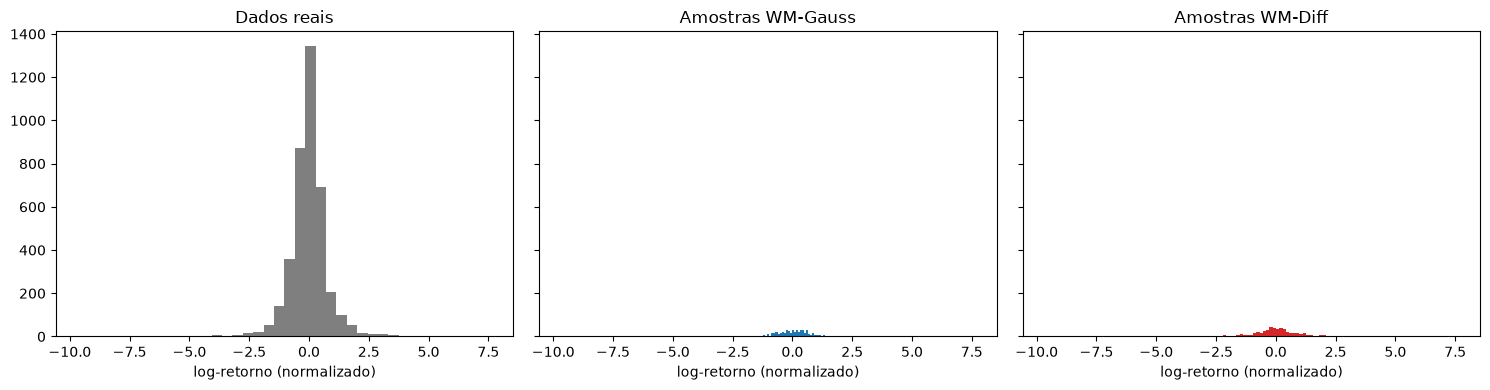

In [ ]:
@torch.no_grad()
def collect_one_step_samples(model: WorldModel, test_norm_df: pd.DataFrame, n_samples=500):
    data = test_norm_df[FEATURE_COLS].values.astype(np.float32)
    ret_idx = FEATURE_COLS.index(TARGET_COL)
    mid = len(data) // 2
    ctx = torch.from_numpy(data[mid - CONTEXT_LEN: mid]).unsqueeze(0)
    h = model.encode(ctx.to(DEVICE))
    if model.head_type == "gauss":
        samples = model.head.sample(h, n_samples=n_samples).squeeze(1)[:, ret_idx]
    else:
        samples = model.head.sample_ddim(h, n_samples=n_samples).squeeze(1)[:, ret_idx]
    return samples.cpu().numpy()

real_returns = test_norm[TARGET_COL].values
samples_gauss = collect_one_step_samples(wm_gauss, test_norm)
samples_diff = collect_one_step_samples(wm_diff, test_norm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
axes[0].hist(real_returns, bins=40, color="tab:gray"); axes[0].set_title("Dados reais")
axes[1].hist(samples_gauss, bins=40, color="tab:blue"); axes[1].set_title("Amostras WM-Gauss")
axes[2].hist(samples_diff, bins=40, color="tab:red"); axes[2].set_title("Amostras WM-Diff")
for ax in axes:
    ax.set_xlabel("log-retorno (normalizado)")
plt.tight_layout()
plt.savefig(FIG_DIR / "painel_histogramas.png", dpi=120)
plt.show()


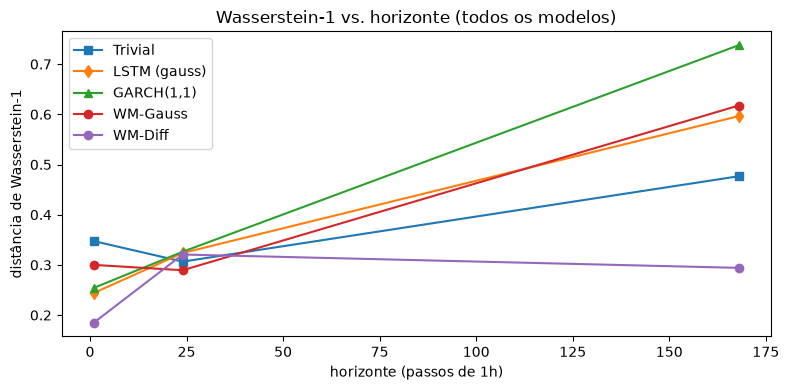

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
_markers = {"Trivial": "s", "GARCH(1,1)": "^", "LSTM (gauss)": "d", "WM-Gauss": "o", "WM-Diff": "o"}
for name, wass in wass_results.items():
    ax.plot(wass["horizon"], wass["wasserstein1"], marker=_markers.get(name, "x"), label=name)
ax.set_xlabel("horizonte (passos de 1h)"); ax.set_ylabel("distância de Wasserstein-1")
ax.set_title("Wasserstein-1 vs. horizonte (todos os modelos)"); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "wasserstein_vs_horizonte.png", dpi=120)
plt.show()


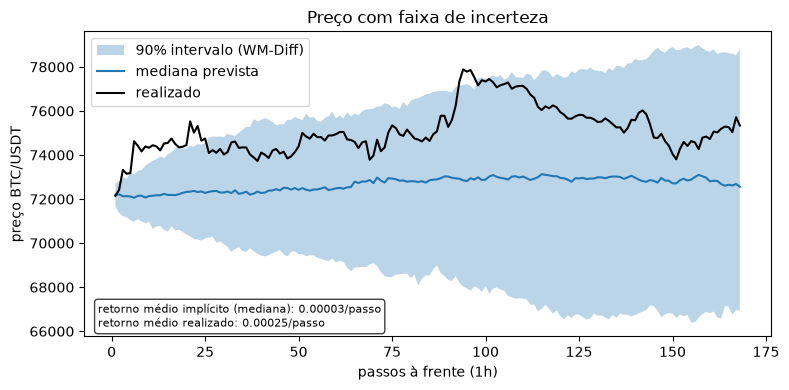

In [ ]:
@torch.no_grad()
def price_band_figure(model: WorldModel, test_norm_df: pd.DataFrame, test_raw_df: pd.DataFrame,
                       start_idx: int, horizon: int, n_samples: int):
    """Série de preço com faixa de incerteza (5-95%) recuperada via cumsum do log-retorno."""
    data = test_norm_df[FEATURE_COLS].values.astype(np.float32)
    ret_idx = FEATURE_COLS.index(TARGET_COL)
    ctx = torch.from_numpy(data[start_idx: start_idx + CONTEXT_LEN]).unsqueeze(0)
    traj = rollout(model, ctx, horizon=horizon, n_samples=n_samples)  # normalizado

    ret_samples = traj[:, :, ret_idx] * feat_std[TARGET_COL] + feat_mean[TARGET_COL]
    cum_log_ret = np.cumsum(ret_samples, axis=1)

    last_close = test_raw_df["close"].values[start_idx + CONTEXT_LEN - 1]
    price_paths = last_close * np.exp(cum_log_ret)

    p05 = np.quantile(price_paths, 0.05, axis=0)
    p50 = np.quantile(price_paths, 0.50, axis=0)
    p95 = np.quantile(price_paths, 0.95, axis=0)
    realized_price = test_raw_df["close"].values[
        start_idx + CONTEXT_LEN: start_idx + CONTEXT_LEN + horizon]
    return p05, p50, p95, realized_price

start_idx = 0
p05, p50, p95, realized_price = price_band_figure(
    wm_diff, test_norm, test_df, start_idx, max(ROLLOUT_HORIZONS), N_ROLLOUT_SAMPLES)

fig, ax = plt.subplots(figsize=(8, 4))
steps = np.arange(1, len(p50) + 1)
ax.fill_between(steps, p05, p95, alpha=0.3, label="90% intervalo (WM-Diff)")
ax.plot(steps, p50, label="mediana prevista")
ax.plot(steps[:len(realized_price)], realized_price, label="realizado", color="black")
ax.set_xlabel("passos à frente (1h)"); ax.set_ylabel("preço BTC/USDT")
ax.legend(); ax.set_title("Preço com faixa de incerteza")

# last_close é local a price_band_figure (não retornado) — recalculado aqui para a anotação
last_close = test_df["close"].values[start_idx + CONTEXT_LEN - 1]
_mean_pred_ret = np.log(p50[-1] / last_close) / len(p50)
_mean_real_ret = (np.log(realized_price[-1] / last_close) / len(realized_price)
                   if len(realized_price) else np.nan)
ax.text(0.02, 0.02,
        f"retorno médio implícito (mediana): {_mean_pred_ret:.5f}/passo\n"
        f"retorno médio realizado: {_mean_real_ret:.5f}/passo",
        transform=ax.transAxes, fontsize=8, va="bottom",
        bbox=dict(boxstyle="round", fc="white", alpha=0.75))
plt.tight_layout()
plt.savefig(FIG_DIR / "preco_faixa_incerteza.png", dpi=120)
plt.show()


**Leitura da mediana achatada:** mesmo com o preço realizado caindo bastante no
período mostrado, a mediana prevista fica perto de um patamar quase constante. Isso
não é necessariamente um erro grosseiro do modelo — é o comportamento esperado ao
integrar (via soma cumulativa dos log-retornos + `exp`) uma previsão de **retorno**
cujo drift estimado é próximo de zero: sem sinal direcional forte nos dados, a
mediana de um processo quase-passeio-aleatório tende a ficar achatada, e é a
**faixa de incerteza** (5–95%) que carrega a informação útil sobre o quão pouco (ou
quanto) se sabe sobre a trajetória futura — no exemplo acima ela cobre o realizado
até perto do fim do horizonte. Vale deixar essa leitura explícita no texto do
projeto/TCC, para não dar a entender que o modelo "errou a direção" quando na
prática ele está dizendo "não há sinal direcional forte, e aqui está o quão incerto
isso fica ao longo do tempo".


In [ ]:
_summary_cols = {}
for _name, _s in summaries.items():
    _summary_cols[(_name, "CRPS")] = _s["crps"]
    _summary_cols[(_name, "PICP")] = _s["picp"]

summary_table = pd.DataFrame(_summary_cols)
summary_table.columns = pd.MultiIndex.from_tuples(summary_table.columns)
_model_order = [m for m in ["Trivial", "GARCH(1,1)", "LSTM (gauss)", "WM-Gauss", "WM-Diff"]
                if m in summaries]
summary_table = summary_table.reindex(columns=_model_order, level=0)
summary_table.to_csv(FIG_DIR / "tabela_resumo_metricas.csv")
summary_table


Trivial           GARCH(1,1)           LSTM (gauss)            \
             CRPS      PICP       CRPS      PICP         CRPS      PICP   
horizon                                                                   
1        0.389131  0.947368   0.357117  1.000000     0.355797  0.947368   
24       0.586246  0.842105   0.577087  0.894737     0.590089  0.789474   
168      0.302096  1.000000   0.332047  1.000000     0.305291  1.000000   

         WM-Gauss             WM-Diff            
             CRPS      PICP      CRPS      PICP  
horizon                                          
1        0.345455  1.000000  0.365101  0.947368  
24       0.580077  0.789474  0.572971  0.842105  
168      0.309574  1.000000  0.268495  1.000000

## 12. Sanity check de implementação (opcional, recomendado antes do treino real)

Valida o DDPM em dados sintéticos gaussianos mistos, onde a solução ótima é conhecida
qualitativamente (mistura bimodal que uma gaussiana única não consegue capturar).

[sanity] epoch 1 loss=0.9571
[sanity] epoch 2 loss=0.9140
[sanity] epoch 3 loss=0.8537
[sanity] epoch 4 loss=0.7520
[sanity] epoch 5 loss=0.7396


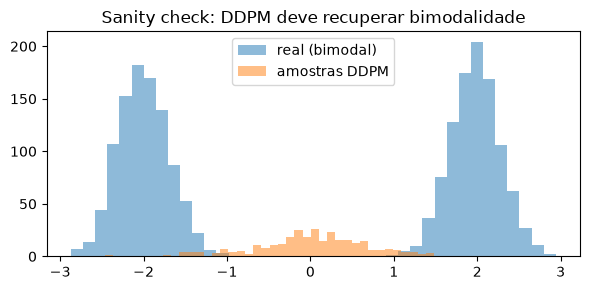

In [ ]:
def sanity_check_synthetic():
    n = 2000
    obs_dim_synth = OBS_DIM
    ctx_len = CONTEXT_LEN
    comp = np.random.binomial(1, 0.5, size=n)
    base = np.where(comp == 1, 2.0, -2.0)
    synth = base[:, None] + 0.3 * np.random.randn(n, obs_dim_synth)
    synth = synth.astype(np.float32)

    class SynthDataset(Dataset):
        def __len__(self):
            return n - ctx_len - 1

        def __getitem__(self, idx):
            return torch.from_numpy(synth[idx: idx + ctx_len]), torch.from_numpy(synth[idx + ctx_len])

    loader = DataLoader(SynthDataset(), batch_size=64, shuffle=True, drop_last=True)
    tiny_diff = WorldModel("diff", n_steps=20).to(DEVICE)
    opt = torch.optim.Adam(tiny_diff.parameters(), lr=1e-3)
    for epoch in range(5):
        losses = []
        for ctx, target in loader:
            ctx, target = ctx.to(DEVICE), target.to(DEVICE)
            opt.zero_grad()
            loss = tiny_diff.step_loss(ctx, target)
            loss.backward(); opt.step()
            losses.append(loss.item())
        print(f"[sanity] epoch {epoch+1} loss={np.mean(losses):.4f}")

    ctx0 = torch.from_numpy(synth[:ctx_len]).unsqueeze(0)
    samples = tiny_diff.sample_next(ctx0, n_samples=300, fast_eval=False).squeeze(1)[:, 0].cpu().numpy()
    plt.figure(figsize=(6, 3))
    plt.hist(synth[:, 0], bins=40, alpha=0.5, label="real (bimodal)")
    plt.hist(samples, bins=40, alpha=0.5, label="amostras DDPM")
    plt.legend(); plt.title("Sanity check: DDPM deve recuperar bimodalidade")
    plt.tight_layout()
    plt.show()

sanity_check_synthetic()
